## Problem Statement:

- For a business it's important to know about the customer retention (Churn).
- In this project we have telecom customer data and we are going to predict the customer churn based on their demography.

#### Dataset understanding:

- customerID: A unique id given to each customer by the business. 
- gender: Customer gender.
- SeniorCitizen - Whether the customer is Senior Citizen (Age > 65).
- Partner - Customer has a partner (In a relationship/not)
- Dependents - Customer has any dependents (Non earning members)
- tenure - From how long the customer is using the service (Months)
- PhoneService - Customer has a telephone services with business or not
- MultipleLines - Customer has multiple telephone lines or not
- InternetService - Customer has an internet connection or not
- OnlineSecurity - Customer uses online security services from the business or not
- OnlineBackup - Customer has online backup services from the business or not
- DeviceProtection - Customer purchased a device protection plan from the business or not
- TechSupport - Customer uses technical support services from the business or not
- StreamingTV - Customer is using streaming tv services from the business or not
- StreamingMovies - Customer uses movie streaming services from the business or not
- Contract - Customer contract type (Monthly, Yearly, Biyearly)
- PaperlessBilling - Customer opted for paperless billing services or not
- PaymentMethod - Customer payment method to pay their bills
- MonthlyCharges - Combined Monthly charges paid by the customer for all services they use
- TotalCharges - Combined charges paid by the customer b ased on their contract
- Churn - Whether the customer will stop using the company services or not

#### Our target column is Churn, we need to predict whether the customer will be churned (Leave company services) or not.

In [1]:
import pandas as pd
pd.set_option('display.max_columns',None)

In [2]:
df = pd.read_csv("Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#### The customer ID column is not adding any significant value in the model so we can drop that column.

In [5]:
df = df.drop("customerID",axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### The database has no null values.

- Now we can see there is a Total charge column with numerical values but its data type is object, which means there are some non-integer values in this column. We have to identify and transfrom them.

In [7]:
df['TotalCharges'] = df['TotalCharges'].str.strip()

In [8]:
import numpy as np

df['TotalCharges'] = df['TotalCharges'].replace('', np.nan)

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [10]:
df.dropna(inplace=True)

- There are blank spaces in some data points so we will replace them with 0, and also we will change the datatype of other data points as well.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [12]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

- Our target column is slightly imbalanced, so the accuracy may not be the best parameter to understand the model performance.
- We will also use f1 score, classification report and ROC-AUC curve to understand the model performance.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, accuracy_score

X = df.drop('Churn',axis=1)
y = df['Churn']

X = pd.get_dummies(data=X,drop_first=True)
y = df['Churn'].map({'No': 0, 'Yes': 1})

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
model_LR1 = LogisticRegression(max_iter=1000)
model_LR1.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [18]:
y_predlr1 = model_LR1.predict(X_test)

In [19]:
print(classification_report(y_test,y_predlr1))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [20]:
model_LR2 = LogisticRegression(max_iter=1000,class_weight='balanced')
model_LR2.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [21]:
y_predlr2 = model_LR2.predict(X_test)

In [22]:
print(classification_report(y_test,y_predlr2))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



In [23]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print(y_res.value_counts())

Churn
1    4130
0    4130
Name: count, dtype: int64


In [24]:
model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_res, y_res)

y_pred_smote = model_smote.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    X, y,
    cv=5,
    scoring='f1'
)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

In [26]:
print("F1 scores:", scores)
print("Average F1:", scores.mean())

F1 scores: [0.63534219 0.64300626 0.62409887 0.61864407 0.61904762]
Average F1: 0.6280278005887001


#### Decision Tree:

In [27]:
from sklearn.tree import DecisionTreeClassifier

In [28]:
model_tree = DecisionTreeClassifier(max_depth=5)
model_tree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [29]:
y_pred_tree = model_tree.predict(X_test)

In [30]:
print("F1 Score Tree: ",f1_score(y_test,y_pred_tree))
print("Classification report Tree: ",classification_report(y_test,y_pred_tree))
print("Accuracy Tree: ",accuracy_score(y_test,y_pred_tree))

F1 Score Tree:  0.58311345646438
Classification report Tree:                precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.59      0.58       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.78      0.78      1407

Accuracy Tree:  0.775408670931059


#### Random Forest:

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

grid.best_params_

{'max_depth': 10, 'n_estimators': 100}

In [32]:
model_RF = RandomForestClassifier(n_estimators=50,max_depth=5,random_state=42, class_weight='balanced')
model_RF.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=50,
                       random_state=42)

In [33]:
y_pred_RF = model_RF.predict(X_test)

In [34]:
print("F1 Score Tree: ",f1_score(y_test,y_pred_RF))
print("Classification report RF: ",classification_report(y_test,y_pred_RF))
print("Accuracy RF: ",accuracy_score(y_test,y_pred_RF))

F1 Score Tree:  0.6227180527383367
Classification report RF:                precision    recall  f1-score   support

           0       0.92      0.70      0.80      1033
           1       0.50      0.82      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.81      0.74      0.75      1407

Accuracy RF:  0.7356076759061834


In [35]:
model_smote_RF = RandomForestClassifier(n_estimators=50,max_depth=5,random_state=42, class_weight='balanced')
model_smote_RF.fit(X_res, y_res)

y_pred_smote_RF = model_smote_RF.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_smote_RF))

              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1033
           1       0.51      0.77      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.75      1407



In [36]:
scores_RF = cross_val_score(
    RandomForestClassifier(n_estimators=50,max_depth=5,random_state=42, class_weight='balanced'),
    X, y,
    cv=5,
    scoring='f1'
)

In [37]:
print("F1 scores RF:", scores_RF)
print("Average F1 RF:", scores_RF.mean())

F1 scores RF: [0.63157895 0.63957219 0.62372188 0.61945032 0.62955032]
Average F1 RF: 0.6287747319192525


- So, the logistic regression is a better model because of the higher average F1 score. The model provided a strong balance between recall and stability.
- While Random Forest achieved slightly higher recall, it was less stable across cross-validation and had lower precision.
- Since churn prediction requires identifying as many potential churn customers as possible while maintaining reliability, Logistic Regression was the better choice.

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Step 1: Model
knn = KNeighborsClassifier(n_neighbors=5)

# Step 2: Train
knn.fit(X_train_scaled, y_train)

# Step 3: Predict
y_pred = knn.predict(X_test_scaled)

# Step 4: Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7526652452025586


In [39]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#### Tensorflow:

In [40]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [42]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7424 - loss: 0.5177 - val_accuracy: 0.7653 - val_loss: 0.4619
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7789 - loss: 0.4518 - val_accuracy: 0.7964 - val_loss: 0.4252
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7969 - loss: 0.4337 - val_accuracy: 0.8044 - val_loss: 0.4142
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7993 - loss: 0.4244 - val_accuracy: 0.8098 - val_loss: 0.4084
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8020 - loss: 0.4199 - val_accuracy: 0.8160 - val_loss: 0.4051
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8058 - loss: 0.4164 - val_accuracy: 0.8151 - val_loss: 0.4029
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8071 - loss: 0.4129 - val_accuracy: 0.8124 - val_loss: 0.4010
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8073 - loss: 0.4119 - val_accuracy: 0.

In [43]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7839 - loss: 0.4425 
Test Accuracy: 0.7839374542236328


In [44]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


In [46]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.5351681957186545


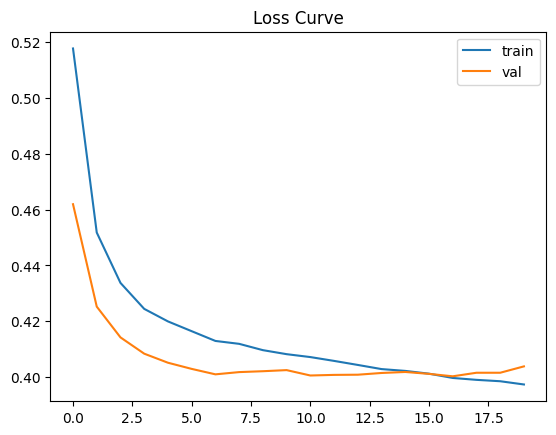

In [45]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.title('Loss Curve')
plt.show()

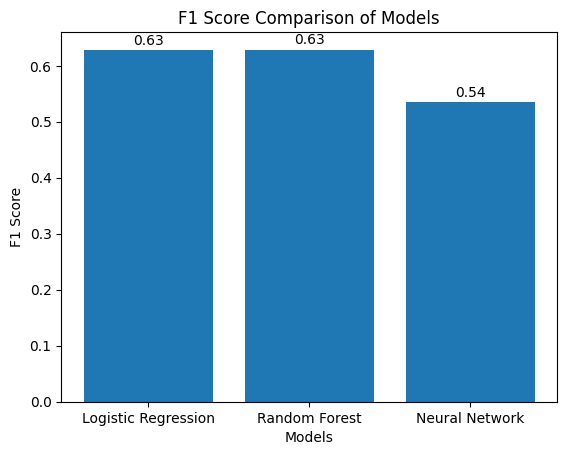

In [48]:
models = ['Logistic Regression', 'Random Forest', 'Neural Network']
f1_scores = [0.6280, 0.6287, 0.5351] 

plt.figure()
plt.bar(models, f1_scores)

plt.title('F1 Score Comparison of Models')
plt.xlabel('Models')
plt.ylabel('F1 Score')

for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.01, str(round(v, 2)), ha='center')

plt.show()

#### Model Deployment:

In [49]:
import joblib

joblib.dump(model_LR2, "churn_model.pkl")

['churn_model.pkl']

In [50]:
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']

In [51]:
print(X.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
